### HEART DISEASE DATA ANALYSIS AND PREDICTION

#### Data Analysis

##### importing libraries



In [1]:
#for heart disease data analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for heart disease prediction 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

 ##### Loading Dataset

In [3]:
df=pd.read_csv("Hearts.csv")
df


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


##### Data Analysis Using Basic Functions on a Dataset

In [5]:
df.index


RangeIndex(start=0, stop=918, step=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [8]:
df.shape

(918, 12)

In [9]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
df.sample()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
38,48,F,ATA,120,177,1,ST,148,N,0.0,Up,0


In [6]:
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [8]:
df.value_counts("Sex")

Sex
M    725
F    193
Name: count, dtype: int64

#### Data cleaning

In [12]:
#check missing values in entire dataset
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [22]:
#ckeck duplicate values
print(df.duplicated().sum()) 

0


In [23]:
df.drop_duplicates(inplace=True)

In [13]:
#check uniques columns in categorical columns
print(df["Sex"].unique())
print(df["ChestPainType"].unique())
print(df["RestingECG"].unique())
print(df["ExerciseAngina"].unique())
print(df["ST_Slope"].unique())

['M' 'F']
['ATA' 'NAP' 'ASY' 'TA']
['Normal' 'ST' 'LVH']
['N' 'Y']
['Up' 'Flat' 'Down']


In [4]:
#add age group column
df["AgeGroup"]=df["Age"].apply(lambda x:"young" if x<40 else "middle Age" if x<=60 else "senior" )
print(df[["Age","AgeGroup"]])

     Age    AgeGroup
0     40  middle Age
1     49  middle Age
2     37       young
3     48  middle Age
4     54  middle Age
..   ...         ...
913   45  middle Age
914   68      senior
915   57  middle Age
916   57  middle Age
917   38       young

[918 rows x 2 columns]


In [5]:
#adding CholesterolStatus column
df["CholesterolStatus"] = df["Cholesterol"].apply(lambda x: "High" if x > 200 else "Normal")
print(df[["Cholesterol","CholesterolStatus"]])

     Cholesterol CholesterolStatus
0            289              High
1            180            Normal
2            283              High
3            214              High
4            195            Normal
..           ...               ...
913          264              High
914          193            Normal
915          131            Normal
916          236              High
917          175            Normal

[918 rows x 2 columns]


##### Data filtering

In [19]:
df[df["Age"]>50]   

0      False
1      False
2      False
3      False
4       True
       ...  
913    False
914     True
915     True
916     True
917    False
Name: Age, Length: 918, dtype: bool

In [33]:
df[df["Age"]<40]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
10,37,F,NAP,130,211,0,Normal,142,N,0.0,Up,0
12,39,M,ATA,120,204,0,Normal,145,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
846,39,M,ASY,118,219,0,Normal,140,N,1.2,Flat,1
856,39,M,NAP,140,321,0,LVH,182,N,0.0,Up,0
892,39,F,NAP,138,220,0,Normal,152,N,0.0,Flat,0
898,35,M,ATA,122,192,0,Normal,174,N,0.0,Up,0


In [59]:
df[df["AgeGroup"]=="young"]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,young,High
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0,young,High
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1,young,High
10,37,F,NAP,130,211,0,Normal,142,N,0.0,Up,0,young,High
12,39,M,ATA,120,204,0,Normal,145,N,0.0,Up,0,young,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,39,M,ASY,118,219,0,Normal,140,N,1.2,Flat,1,young,High
856,39,M,NAP,140,321,0,LVH,182,N,0.0,Up,0,young,High
892,39,F,NAP,138,220,0,Normal,152,N,0.0,Flat,0,young,High
898,35,M,ATA,122,192,0,Normal,174,N,0.0,Up,0,young,Normal


In [31]:
# patients who are age greater than 50 and having heart disease
df[(df["Age"] > 50) & (df["HeartDisease"] == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
11,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
18,60,M,ASY,100,248,0,Normal,125,N,1.0,Flat,1
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
32,54,M,ASY,125,224,0,Normal,122,N,2.0,Flat,1
36,65,M,ASY,140,306,1,Normal,87,Y,1.5,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1


In [32]:
# patients who are age greater than 50 and having heart disease
df[(df["Age"] > 50) & (df["HeartDisease"] == 0)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
15,54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0
26,53,M,ASY,124,260,0,ST,112,Y,3.0,Flat,0
27,52,M,ATA,120,284,0,Normal,118,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
894,58,F,ASY,130,197,0,Normal,131,N,0.6,Flat,0
902,58,M,ATA,125,220,0,Normal,144,N,0.4,Flat,0
903,56,M,ATA,130,221,0,LVH,163,N,0.0,Up,0
904,56,M,ATA,120,240,0,Normal,169,N,0.0,Down,0


In [34]:
df[(df["Cholesterol"] > 200) & (df["RestingBP"] > 140)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
23,44,M,ATA,150,288,0,Normal,150,Y,3.0,Flat,1
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
39,48,F,ASY,150,227,0,Normal,130,Y,1.0,Flat,0
40,54,F,ATA,150,230,0,Normal,130,N,0.0,Up,0
42,35,M,ATA,150,264,0,Normal,168,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
891,66,F,NAP,146,278,0,LVH,152,N,0.0,Flat,0
893,57,M,ATA,154,232,0,LVH,164,N,0.0,Up,1
899,61,M,ASY,148,203,0,Normal,161,N,0.0,Up,1
901,58,F,ASY,170,225,1,LVH,146,Y,2.8,Flat,1


In [35]:
df[(df["Cholesterol"] > 200) & (df["HeartDisease"] == 1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
13,49,M,ASY,140,234,0,Normal,140,Y,1.0,Flat,1
18,60,M,ASY,100,248,0,Normal,125,N,1.0,Flat,1
19,36,M,ATA,120,267,0,Normal,160,N,3.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
901,58,F,ASY,170,225,1,LVH,146,Y,2.8,Flat,1
905,67,M,NAP,152,212,0,LVH,150,N,0.8,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1


In [60]:
df[df["CholesterolStatus"] == "High"]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,middle Age,High
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,young,High
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,middle Age,High
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0,young,High
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0,middle Age,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,67,M,NAP,152,212,0,LVH,150,N,0.8,Flat,1,senior,High
906,55,F,ATA,132,342,0,Normal,166,N,1.2,Up,0,middle Age,High
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1,middle Age,High
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,middle Age,High


#### Grouping

In [22]:
#avg age by gender
df.groupby("Sex")["Age"].mean()

Sex
F    52.492228
M    53.782069
Name: Age, dtype: float64

In [75]:
#avg choloestrol by gender
df.groupby("Sex")["Cholesterol"].mean()

Sex
F    241.196891
M    187.513103
Name: Cholesterol, dtype: float64

In [65]:
# heart disease cases by gender
df.groupby("Sex")["HeartDisease"].sum()

Sex
F     50
M    458
Name: HeartDisease, dtype: int64

In [67]:
#Average Age by Heart Disease Status
df.groupby("HeartDisease")["Age"].mean()

HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

In [24]:
#number of patients in each group
df.groupby("AgeGroup").size()

AgeGroup
middle Age    617
senior        221
young          80
dtype: int64

In [70]:
#average cholestrol by age group
df.groupby("AgeGroup")["Cholesterol"].mean()

AgeGroup
middle Age    204.614263
senior        180.873303
young         203.475000
Name: Cholesterol, dtype: float64

In [76]:
df.groupby("ChestPainType")["HeartDisease"].sum()

ChestPainType
ASY    392
ATA     24
NAP     72
TA      20
Name: HeartDisease, dtype: int64

In [77]:
# number of people in Age group wise 
df.groupby("AgeGroup").size()

AgeGroup
middle Age    617
senior        221
young          80
dtype: int64

#### Aggregations

In [88]:
df.min() 

Age                          28
Sex                           F
ChestPainType               ASY
RestingBP                     0
Cholesterol                   0
FastingBS                     0
RestingECG                  LVH
MaxHR                        60
ExerciseAngina                N
Oldpeak                    -2.6
ST_Slope                   Down
HeartDisease                  0
AgeGroup             middle Age
CholesterolStatus          High
dtype: object

In [89]:
df.max()

Age                      77
Sex                       M
ChestPainType            TA
RestingBP               200
Cholesterol             603
FastingBS                 1
RestingECG               ST
MaxHR                   202
ExerciseAngina            Y
Oldpeak                 6.2
ST_Slope                 Up
HeartDisease              1
AgeGroup              young
CholesterolStatus    Normal
dtype: object

In [6]:
#mean values of all numeric columns
print(df.mean(numeric_only=True))

Age              53.510893
RestingBP       132.396514
Cholesterol     198.799564
FastingBS         0.233115
MaxHR           136.809368
Oldpeak           0.887364
HeartDisease      0.553377
dtype: float64


In [92]:
df.median(numeric_only=True)

Age              54.0
RestingBP       130.0
Cholesterol     223.0
FastingBS         0.0
MaxHR           138.0
Oldpeak           0.6
HeartDisease      1.0
dtype: float64

In [93]:
df["Age"].var()

88.97425416307314

In [94]:
df["Age"].mode()

0    54
Name: Age, dtype: int64

#### Sorting

In [95]:
df.sort_values("Age")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
208,28,M,ATA,130,132,0,LVH,185,N,0.0,Up,0,young,Normal
219,29,M,ATA,140,263,0,Normal,170,N,0.0,Up,0,young,High
170,29,M,ATA,120,243,0,Normal,160,N,0.0,Up,0,young,High
829,29,M,ATA,130,204,0,LVH,202,N,0.0,Up,0,young,High
215,30,F,TA,170,237,0,ST,170,N,0.0,Up,0,young,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,75,M,ASY,170,203,1,ST,108,N,0.0,Flat,1,senior,High
541,76,M,NAP,104,113,0,LVH,120,N,3.5,Down,1,senior,Normal
688,76,F,NAP,140,197,0,ST,116,N,1.1,Flat,0,senior,Normal
814,77,M,ASY,125,304,0,LVH,162,Y,0.0,Up,1,senior,High


In [28]:
df.sort_values("Age",ascending=False)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup
814,77,M,ASY,125,304,0,LVH,162,Y,0.0,Up,1,senior
447,77,M,ASY,124,171,0,ST,110,Y,2.0,Up,1,senior
688,76,F,NAP,140,197,0,ST,116,N,1.1,Flat,0,senior
541,76,M,NAP,104,113,0,LVH,120,N,3.5,Down,1,senior
556,75,M,ASY,160,310,1,Normal,112,Y,2.0,Down,0,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,30,F,TA,170,237,0,ST,170,N,0.0,Up,0,young
219,29,M,ATA,140,263,0,Normal,170,N,0.0,Up,0,young
829,29,M,ATA,130,204,0,LVH,202,N,0.0,Up,0,young
170,29,M,ATA,120,243,0,Normal,160,N,0.0,Up,0,young


In [30]:
df[(df["Age"] > 40) & (df["Age"] < 60)].sort_values("Age")   

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup
797,41,M,ASY,110,172,0,LVH,158,N,0.0,Up,1,middle Age
49,41,M,ASY,110,289,0,Normal,170,N,0.0,Flat,1,middle Age
726,41,M,ATA,110,235,0,Normal,153,N,0.0,Up,0,middle Age
154,41,M,ATA,120,291,0,ST,160,N,0.0,Up,0,middle Age
698,41,M,NAP,130,214,0,LVH,168,N,2.0,Flat,0,middle Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...
464,59,M,NAP,131,0,0,Normal,128,Y,2.0,Down,1,middle Age
475,59,M,ASY,178,0,1,LVH,120,Y,0.0,Flat,1,middle Age
869,59,M,NAP,150,212,1,Normal,157,N,1.6,Up,0,middle Age
622,59,M,ASY,110,239,0,LVH,142,Y,1.2,Flat,1,middle Age


In [98]:
df.sort_values(["HeartDisease","Age"]) 

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
208,28,M,ATA,130,132,0,LVH,185,N,0.0,Up,0,young,Normal
170,29,M,ATA,120,243,0,Normal,160,N,0.0,Up,0,young,High
219,29,M,ATA,140,263,0,Normal,170,N,0.0,Up,0,young,High
829,29,M,ATA,130,204,0,LVH,202,N,0.0,Up,0,young,High
215,30,F,TA,170,237,0,ST,170,N,0.0,Up,0,young,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,75,M,ASY,170,203,1,ST,108,N,0.0,Flat,1,senior,High
506,75,M,ASY,136,225,0,Normal,112,Y,3.0,Flat,1,senior,High
541,76,M,NAP,104,113,0,LVH,120,N,3.5,Down,1,senior,Normal
447,77,M,ASY,124,171,0,ST,110,Y,2.0,Up,1,senior,Normal


In [99]:
df.sort_values("AgeGroup")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,middle Age,High
433,46,M,ASY,110,236,0,Normal,125,Y,2.0,Flat,1,middle Age,High
435,60,M,ASY,152,0,0,ST,118,Y,0.0,Up,0,middle Age,Normal
436,58,M,ASY,116,0,0,Normal,124,N,1.0,Up,1,middle Age,Normal
440,52,M,NAP,128,0,0,ST,180,N,3.0,Up,1,middle Age,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,34,M,ATA,98,220,0,Normal,150,N,0.0,Up,0,young,High
271,32,F,ATA,105,198,0,Normal,165,N,0.0,Up,0,young,Normal
289,36,M,ATA,120,166,0,Normal,180,N,0.0,Up,0,young,Normal
229,37,F,ASY,130,173,0,ST,184,N,0.0,Up,0,young,Normal


In [100]:
df.sort_values("Cholesterol", ascending=False)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1,middle Age,High
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0,senior,High
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1,young,High
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1,middle Age,High
250,44,M,ASY,135,491,0,Normal,135,N,0.0,Flat,1,middle Age,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,57,M,ASY,160,0,1,Normal,98,Y,2.0,Flat,1,middle Age,Normal
393,38,M,ASY,150,0,1,Normal,120,Y,0.7,Flat,1,young,Normal
392,61,M,ASY,130,0,0,LVH,115,N,0.0,Flat,1,senior,Normal
391,70,M,ASY,115,0,0,ST,92,Y,0.0,Flat,1,senior,Normal


#### Data Overview from analysis using queries

In [109]:
print("total no of patients :",len(df))
print("average age of patients ",df["Age"].mean())
print("maximum age of patients ",df["Age"].max())
print("minimum age of patients ",df["Age"].min())
print("maximum cholestrol level :",df["Cholesterol"].max())
print("patients gender wisely :",df["Sex"].value_counts())

total no of patients : 918
average age of patients  53.510893246187365
maximum age of patients  77
minimum age of patients  28
maximum cholestrol level : 603
patients gender wisely : Sex
M    725
F    193
Name: count, dtype: int64


In [32]:
print("--->count of patients with heart disease: ",df["HeartDisease"].value_counts()[1])

print("--->count of patients without heart disease: ",df["HeartDisease"].value_counts()[0])

print("--->percentage of patients with heart disease:",df["HeartDisease"].mean()*100)

print("--->patients with heart disease count gender wise  : ")
print(df.groupby("Sex")["HeartDisease"].sum())

print("--->patients classified based on Age group: ",df["AgeGroup"].value_counts())



--->count of patients with heart disease:  508
--->count of patients without heart disease:  410
--->percentage of patients with heart disease: 55.33769063180828
--->patients with heart disease count gender wise  : 
Sex
F     50
M    458
Name: HeartDisease, dtype: int64
--->patients classified based on Age group:  AgeGroup
middle Age    617
senior        221
young          80
Name: count, dtype: int64


In [74]:
print("Average cholestrol level:",df["Cholesterol"].mean())

print("average resting blood pressure:",df["RestingBP"].mean())

print("Exercise angina vs heart disease:",df.groupby("ExerciseAngina")["HeartDisease"].count())

Average cholestrol level: 198.7995642701525
average resting blood pressure: 132.39651416122004
Exercise angina vs heart disease: ExerciseAngina
N    547
Y    371
Name: HeartDisease, dtype: int64


In [83]:
df.groupby(["Sex", "AgeGroup"])["HeartDisease"].mean()

Sex  AgeGroup  
F    middle Age    0.217054
     senior        0.422222
     young         0.157895
M    middle Age    0.600410
     senior        0.806818
     young         0.377049
Name: HeartDisease, dtype: float64

In [145]:
print("Blood pressure contributes to risk")
df.groupby("HeartDisease")["RestingBP"].mean()

Blood pressure contributes to risk


HeartDisease
0    130.180488
1    134.185039
Name: RestingBP, dtype: float64

In [144]:
print("Max Heart Rate behavior")
print(df.groupby("HeartDisease")["MaxHR"].mean())

Max Heart Rate behavior
HeartDisease
0    148.151220
1    127.655512
Name: MaxHR, dtype: float64


#### DATA VISUALIZATION

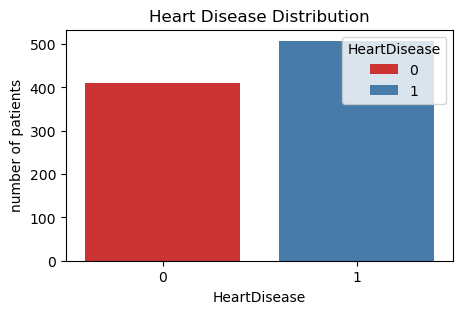

In [39]:
plt.figure(figsize=(5,3))
sns.countplot(
    x="HeartDisease",
    hue="HeartDisease",
    data=df,
    palette="Set1"
    
)
plt.title("Heart Disease Distribution")
plt.ylabel("number of patients")
plt.show()

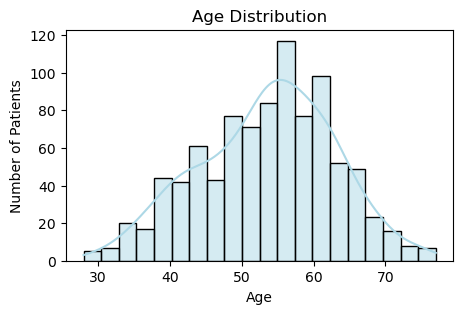

In [8]:
plt.figure(figsize=(5,3))
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color="lightblue"
)
plt.title("Age Distribution")
plt.ylabel("Number of Patients")
plt.show()

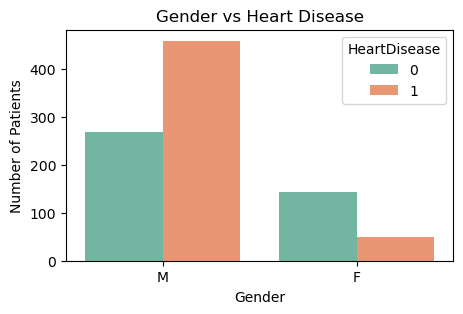

In [51]:
plt.figure(figsize=(5,3))
sns.countplot(
    x="Sex",
    hue="HeartDisease",
    data=df,
    palette="Set2"
)
plt.title("Gender vs Heart Disease")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

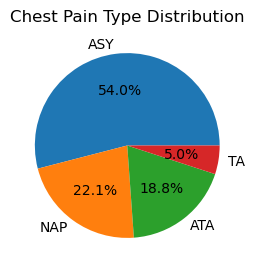

In [56]:
plt.figure(figsize=(5,3))
df["ChestPainType"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Chest Pain Type Distribution")
plt.ylabel("")
plt.show()

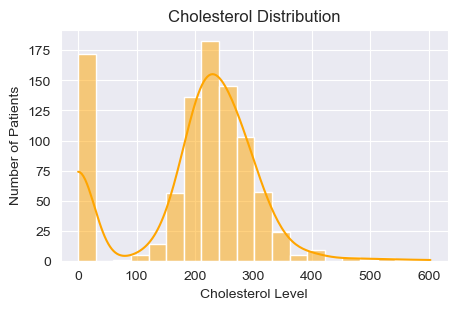

In [229]:
plt.figure(figsize=(5,3))
sns.histplot(
    data=df,
    x="Cholesterol",
    bins=20,
    kde=True,
    color="orange"
)        
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Number of Patients")
plt.show()

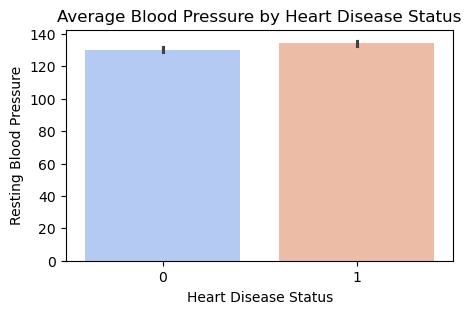

In [58]:
plt.figure(figsize=(5,3))
sns.barplot(
    x="HeartDisease",
    y="RestingBP",
    data=df,
    palette="coolwarm",
    hue="HeartDisease",
    legend=False
)
plt.title("Average Blood Pressure by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Resting Blood Pressure")

plt.show()

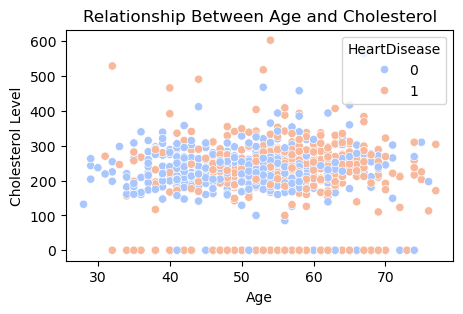

In [62]:
plt.figure(figsize=(5,3))
sns.scatterplot(
    x="Age",
    y="Cholesterol",
    data=df,
    hue="HeartDisease",
    palette="coolwarm"
)
plt.title("Relationship Between Age and Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol Level")
plt.show()

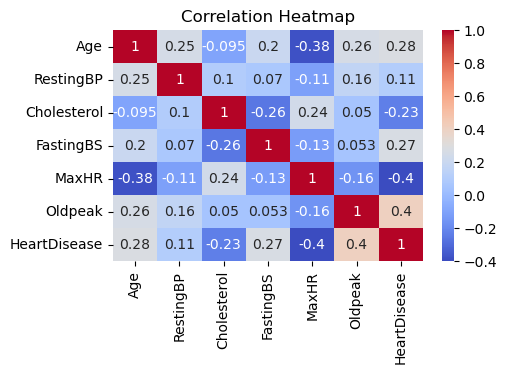

In [64]:
plt.figure(figsize=(5,3))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

##### Heart disease Prediction

In [9]:
#copying processing dataset into model_df variable 
model_df=df.copy()

In [10]:
#coverting categorical values into numeric values 
le=LabelEncoder()
model_df["Sex"]=le.fit_transform(model_df["Sex"])

model_df["ChestPainType"]=le.fit_transform(model_df["ChestPainType"])

model_df["RestingECG"]=le.fit_transform(model_df["RestingECG"])

model_df["ExerciseAngina"]=le.fit_transform(model_df["ExerciseAngina"])

model_df["AgeGroup"]=le.fit_transform(model_df["AgeGroup"])

model_df["CholesterolStatus"]=le.fit_transform(model_df["CholesterolStatus"])

model_df["ST_Slope"]=le.fit_transform(model_df["ST_Slope"])



In [78]:
model_df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,CholesterolStatus
0,40,1,1,140,289,0,1,172,0,0.0,2,0,0,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1,0,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0,2,0


In [11]:
#intialising features and targets
x=model_df.drop(columns=["HeartDisease"]) 
y=model_df["HeartDisease"]

In [12]:
#split the data for training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
#Training model
NB=GaussianNB()
NB.fit(x_train,y_train) 

,priors,None
,var_smoothing,1e-09


In [14]:
#prediction on test data
y_pred=NB.predict(x_test)
print("Predicted values: ")
print(y_pred)
print("Actual values: ")
print(y_test)   

Predicted values: 
[0 1 1 1 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1
 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1
 0 1 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 0 1 1 0 0
 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 0 0
 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1]
Actual values: 
668    0
30     1
377    1
535    1
807    0
      ..
211    1
745    1
584    1
878    0
451    1
Name: HeartDisease, Length: 184, dtype: int64


In [15]:
print("accuracy score:",accuracy_score(y_test,y_pred)*100)

accuracy score: 84.23913043478261


In [93]:
##prediction on new data
prediction = NB.predict([[45,1,2,120,240,0,1,150,0,1.5,1,0,1]])
if prediction[0] == 1:
    print("Heart Disease Detected")
else:                                              
    print("No Heart Disease Detected")

No Heart Disease Detected
